# Skill level 1: Steady-state calculations of thermal loads in winter and summer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Plan of the building


*texte en italique*# Draw of the plan of a two-zone building



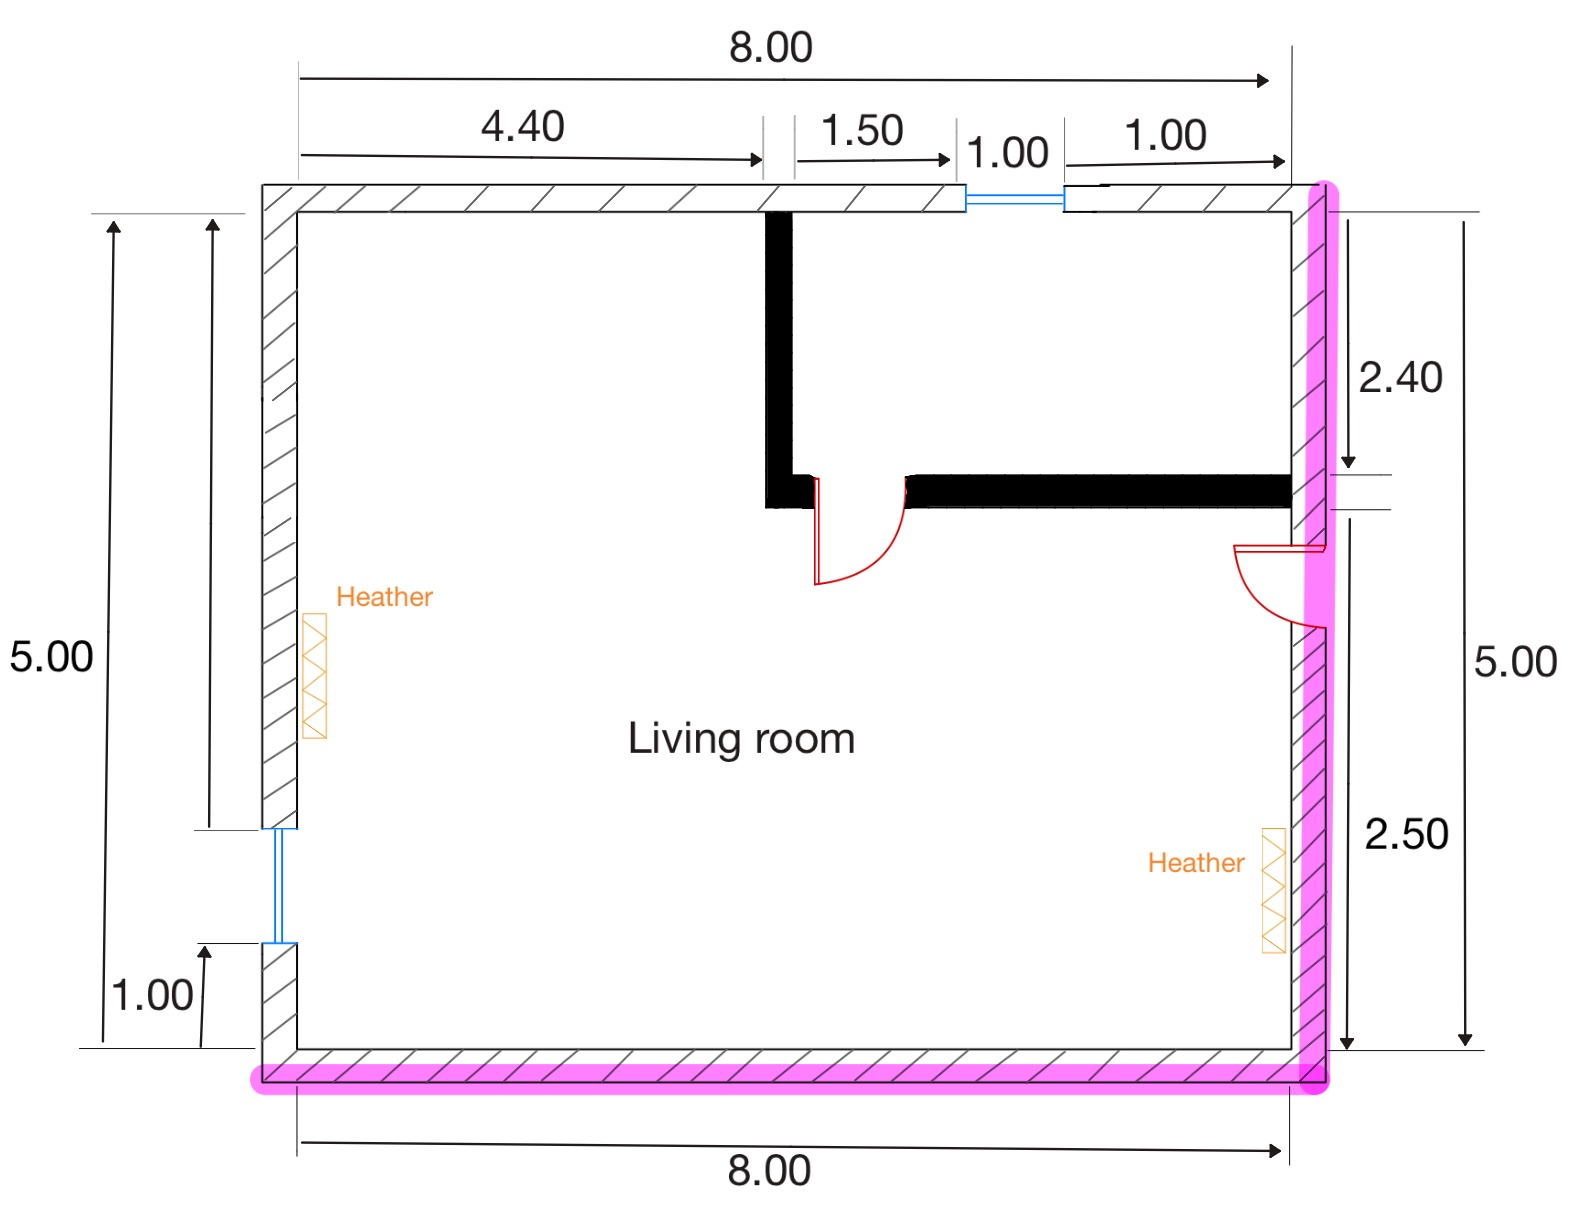




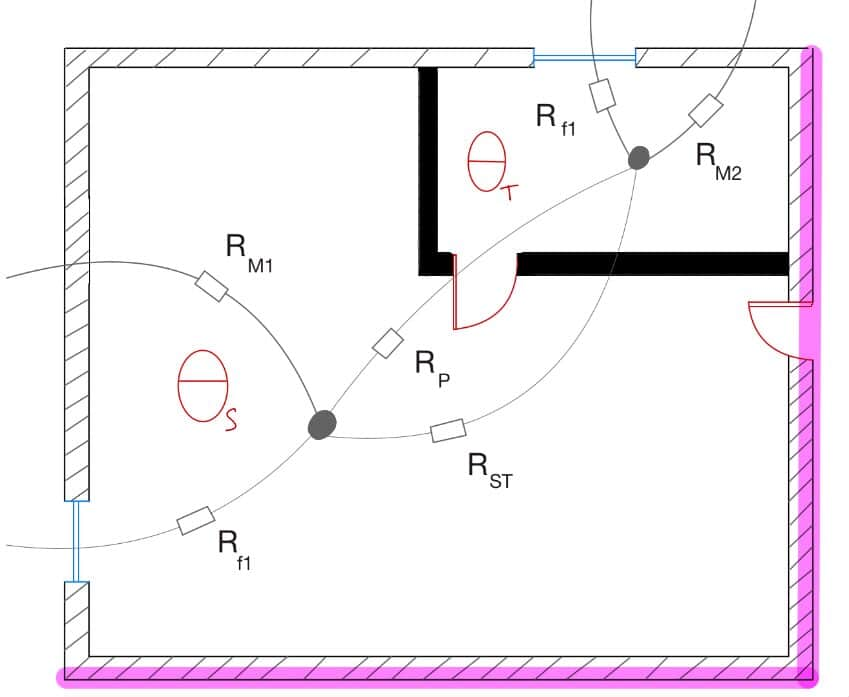

# Hypothesis for boundary conditions.

1.   We consider that the ceiling and the ground are adiabatic, therefore there are no exchanges of heat on those surfaces
2.   Steady-state assumption: $\frac{\partial T}{\partial t} = 0$
3.  Equivalent homogeneous walls : Heat flow through each wall uses Fourier’s law:  $\phi = \frac{T_{int}- T_{ext}}{R}$
4.   Simplified convection and radiation: Use constant convective heat transfer coefficients : $h_{int}, h_{ext}$
5. We consider that the right and bottom walls are adiabatic due to the presence of a house next to our building. Only the walls oriented to the south are exposed to the sun.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dm4bem

For the materials we chose :

*   Wall : we consider a concrete ([concrete data](https://energieplus-lesite.be/donnees/enveloppe44/enveloppe2/conductivite-thermique-des-materiaux/#Les_blocs_de_beton_avec_granulats_ordinaires)) wall isolated with wood fiber in the interior ([Isonat Flex 40](https://www.isover.fr/nous-connaitre/nos-actualites/isonat-flex-40-lisolant-bio-source-le-plus-economique-du-marche))
*   Wall between the living room and the toilets (
*   Window : we chose the helleux menuiseries window ([HM window properties](https://www.helleux.fr/conseils/89-qu-est-ce-que-le-coefficient-thermique-d-une-fenetre-ug-uf-uw.html))


See the drawings after.

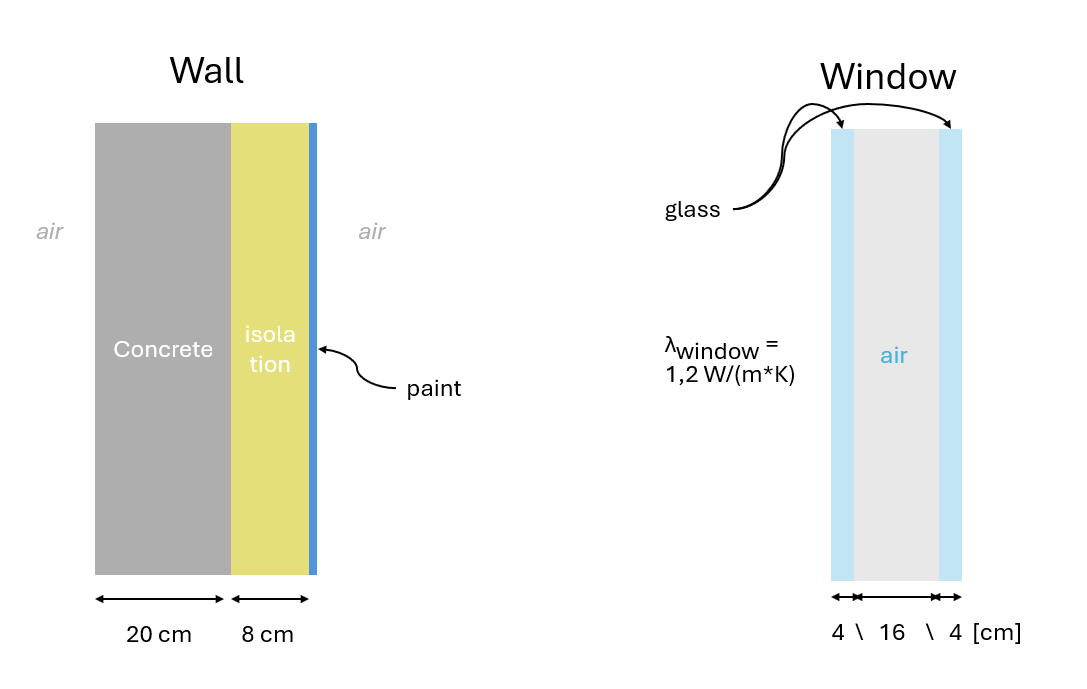

### **Elecal** scheme

# Calculate the thermal conductances for conduction


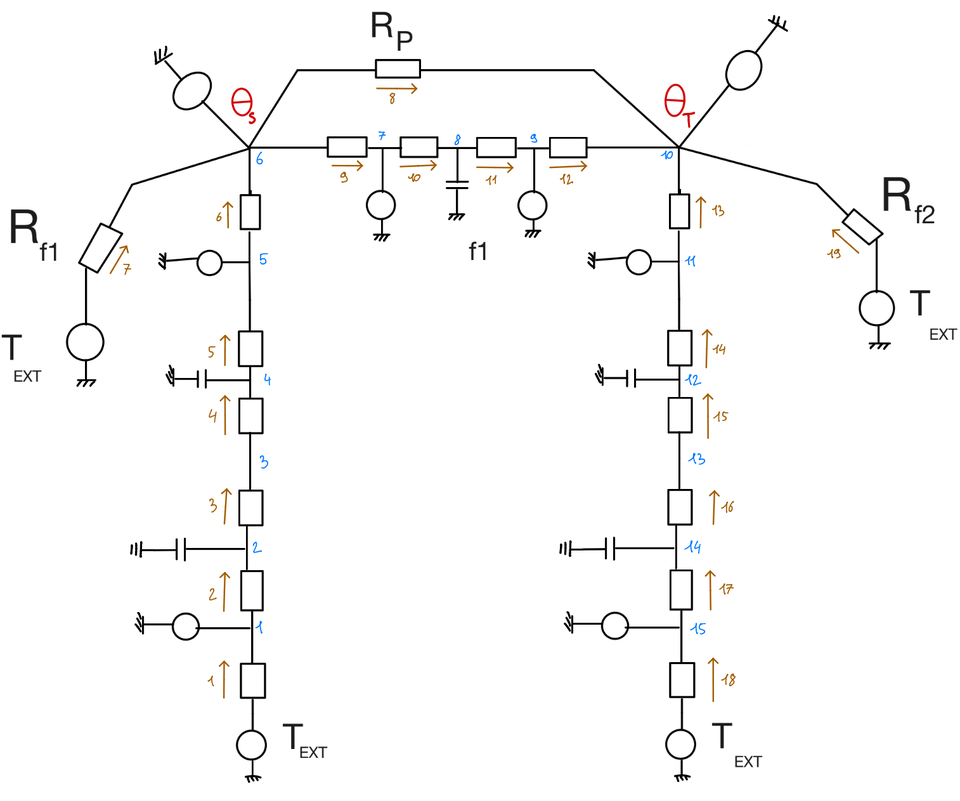

Let's evaluate the overall thermal conductivity of the wall, which comprises two primary constituents: concrete and insulation:

$$
\lambda_{\text{eq}} = \frac{\text{Total Width}}{\text{Total Resistance (R)}} = \frac{\sum_{i=1}^{n} e_i}{\sum_{i=1}^{n} \frac{e_i}{\lambda_i}}
$$

Furthermore, for the equivalent heat capacity:

$$
c_{\text{eq}} = \frac{\text{Total Heat Capacity}}{\text{Total Mass}} = \frac{\sum_{i=1}^{n} \rho_i \cdot c_i \cdot e_i}{\sum_{i=1}^{n} \rho_i \cdot e_i}
$$

At this stage, we determine the conductive thermal conductance $G_{\text{cd}}$, which measures how easily thermal energy travels through the wall. This parameter relies on the material's thermal conductivity, the thickness, and the cross-sectional area:

$$
G_{\text{cd}} = \frac{\lambda}{e} \cdot S
$$


# Calculate the thermal conductances for convection


At this point, we evaluate the **convective thermal power** $ G $ moving across the wall and the glazing. This quantity relies on the inside and outside heat transfer coefficients ($ h_{\text{in}}, h_{\text{out}} $), the respective surface areas ($ S_{\text{wall}}, S_{\text{glass}} $), and the overall temperature variance between the interior and exterior ($ \Delta T $).

For the wall, the convective heat transfer power is given by:

$$
G_{\text{wall}} = \left( h_{\text{in}} \cdot S_{\text{wall}} + h_{\text{out}} \cdot S_{\text{wall}} \right) \cdot \Delta T
$$

Meanwhile, for the glass, the equation is:

$$
G_{\text{glass}} = \left( h_{\text{in}} \cdot S_{\text{glass}} + h_{\text{out}} \cdot S_{\text{glass}} \right) \cdot \Delta T
$$

These mathematical relations are derived from the standard convective heat transfer equation:

$$
\Phi = h \cdot S \cdot \Delta T = G \cdot \Delta T
$$

representing the sum of the convective contributions from both the interior and exterior surfaces.

For the heat transfer coefficient, we selected:

$
h = 25 \text{W/(m²·K)}
$ for the exterior walls and
$
h = 8 \text{W/(m²·K)}
$
for the interior walls between the living-room and the toilet

# Calculate the thermal conductances for long-wave radiation

# Calculate the thermal conductances for advection (heater and ventilation)

In [ ]:
import numpy as np

# ventilation flow rate
Va = 40*2.5                   # m³, volume of air
ACH = 1                     # 1/h, air changes per hour
Va_dot = ACH / 3600 * Va    # m³/s, air infiltration

# Define properties for air (typical values)
air = {'Density': 1.2, 'Specific heat': 1005}

# ventilation & advection
Gv = air['Density'] * air['Specific heat'] * Va_dot

## Calculations for the thermal resistance of the wall

# Calculate the thermal capacities

At this step, we compute the thermal capacities of the building elements (wall and air).  
These values represent the amount of energy required to increase the temperature of the corresponding element by one kelvin.  
They are essential for modeling the dynamic thermal behavior of the system.

The general formula for thermal capacity is:

$$
C = \rho \cdot c \cdot e \cdot S
$$



*   $\rho$ is the density [kg/m³]
*   c is the specific heat [J/(kg·K)]
*   e is the thickness [m]
*   S is the surface area [m²]

This gives us a scalar value for each component that will be used in the thermal model to account for their respective thermal inertias.



# Define the inputs: temperature sources and flow rate sources

# Write in Python the incidence matrix A, the conductance matrix G and the capacity matrix C of the system of Algebraic Differential Equations (DAE)

During this phase, we determine the inner temperature profile of the system by incorporating internal heat sources and radiative heat fluxes.

The internal and external radiative fluxes are evaluated using the equations below:

$$
\Phi_o = \alpha_{\text{wSW}} \cdot E  \quad \text{[W/m^3]}
$$

$$
\Phi_i = \tau_{\text{gSW}} \cdot \alpha_{\text{gSW}} \cdot E \quad \text{[W/m^3]}
$$

Where:
* $ \alpha_{\text{wSW}} $ stands for the short-wave absorptivity of the wall,
* $ \alpha_{\text{gSW}} $ stands for the short-wave absorptivity of the glass,
* $ \tau_{\text{gSW}} $ represents the short-wave transmittance of the glass,
* $ E $ is the overall irradiance incident upon the glass or wall,
* $ S $ denotes the surface area of the window or wall.

Following this, we find the temperature profile $ \theta $ by solving a linear system of equations that incorporates both the heat fluxes and the internal heat generation $ Q_a $ (such as those from equipment and occupants). This system is formulated as:

$$
\theta = (A^T G^{-1} A)^{-1} A^T G^{-1} b
$$

Where:
* $ A $ corresponds to the coefficient matrix,
* $ G $ represents the conductance matrix,
* $ b $ is the vector of boundary conditions (representing temperatures).

Ultimately, the resulting temperature vector $ \theta $ yields the temperature at every node across the system.



In [ ]:
import numpy as np

# 1. PARAMÈTRES GÉOMÉTRIQUES ET THERMIQUES (Déduits de tes images)
h_plafond = 2.5 # Hauteur sous plafond standard estimée (en m)


S_fenetre1 = 1.0 * 1.2 # Fenêtre du Salon
S_fenetre2 = 1.0 * 1.2 # Fenêtre de la Toilet
S_porte = 0.8 * 2.0    # Porte intérieure

S_wall1 = (5.00 + 4.40) * h_plafond - S_fenetre1 # Mur extérieur du Salon
S_wall2 = (1.50 + 1.00 + 1.00) * h_plafond - S_fenetre2 # Mur extérieur de la Toilet
S_part = (2.40 + 3.60) * h_plafond - S_porte # Cloison séparative

# Propriétés thermiques des matériaux
e_beton = 0.20
lam_beton = 1.7
e_iso = 0.10
lam_iso = 0.038
e_part = 0.10
lam_part = 0.4

# Coefficients de transmission (U) et de convection (h)
U_fenetre = 1.3
U_porte = 2.0
h_in = 8.0   # Convection intérieure
h_out = 25.0 # Convection extérieure

# 2. CALCUL DES CONDUCTANCES (G = 1 / Résistance thermique)

# Salon
G1 = h_out * S_wall1
G2 = (lam_beton / (e_beton / 2)) * S_wall1
G3 = (lam_beton / (e_beton / 2)) * S_wall1
G4 = (lam_iso / (e_iso / 2)) * S_wall1
G5 = (lam_iso / (e_iso / 2)) * S_wall1
G6 = h_in * S_wall1
G_f1 = U_fenetre * S_fenetre1

# Porte interne
G_p = U_porte * S_porte

# Cloison
G9 = h_in * S_part
G10 = (lam_part / (e_part / 2)) * S_part
G11 = (lam_part / (e_part / 2)) * S_part
G12 = h_in * S_part

# Toilet
G13 = h_in * S_wall2
G14 = (lam_iso / (e_iso / 2)) * S_wall2
G15 = (lam_iso / (e_iso / 2)) * S_wall2
G16 = (lam_beton / (e_beton / 2)) * S_wall2
G17 = (lam_beton / (e_beton / 2)) * S_wall2
G18 = h_out * S_wall2
G_f2 = U_fenetre * S_fenetre2

# Matrice Diagonale des 19 branches
G = np.diag([G1, G2, G3, G4, G5, G6, G_f1, G_p, G9, G10, G11, G12, G13, G14, G15, G16, G17, G18, G_f2])

# 3. MATRICE D'INCIDENCE (A) : 19 branches x 15 Noeuds
A = np.zeros((19, 15))

# Mur Extérieur Salon
A[0, 0] = 1
A[1, 0], A[1, 1] = -1, 1
A[2, 1], A[2, 2] = -1, 1
A[3, 2], A[3, 3] = -1, 1
A[4, 3], A[4, 4] = -1, 1
A[5, 4], A[5, 5] = -1, 1
A[6, 5] = 1 # Fenêtre 1

# Cloison interne et Porte
A[7, 5], A[7, 9] = -1, 1 # Porte
A[8, 5], A[8, 6] = -1, 1 # Cloison
A[9, 6], A[9, 7] = -1, 1
A[10, 7], A[10, 8] = -1, 1
A[11, 8], A[11, 9] = -1, 1

# Mur Extérieur Toilet
A[12, 10], A[12, 9] = -1, 1
A[13, 11], A[13, 10] = -1, 1
A[14, 12], A[14, 11] = -1, 1
A[15, 13], A[15, 12] = -1, 1
A[16, 14], A[16, 13] = -1, 1
A[17, 14] = 1
A[18, 9] = 1 # Fenêtre 2

# 4. VECTEURS TEMPÉRATURE EXTÉRIEURE (b) ET CHAUFFAGE (f)
T_ext = 10.0
b = np.zeros(19)
b[0] = b[6] = b[17] = b[18] = T_ext

f = np.zeros(15)
f[5] = 1500  # Index 5 correspond au Noeud 6 (Salon)
f[9] = 750   # Index 9 correspond au Noeud 10 (Toilet)

# 5. RÉSOLUTION MATRICIELLE DU SYSTÈME (Steady State)
theta = np.linalg.inv(A.T @ G @ A) @ (A.T @ G @ b + f)

print(f"Température du Salon   : {theta[5]:.2f} °C")
print(f"Température de Toilet : {theta[9]:.2f} °C")

Température du Salon   : 177.89 °C
Température de Toilet : 179.45 °C


Note that the temperatures are very high, particularly because air renewal is not taken into account. The version below does:

In [ ]:
import numpy as np

# 1. PARAMÈTRES GÉOMÉTRIQUES ET THERMIQUES
h_plafond = 2.5

S_fenetre1 = 1.0 * 1.2
S_fenetre2 = 1.0 * 1.2
S_porte = 0.8 * 2.0

S_wall1 = (5.00 + 4.40) * h_plafond - S_fenetre1
S_wall2 = (1.50 + 1.00 + 1.00) * h_plafond - S_fenetre2
S_part = (2.40 + 3.60) * h_plafond - S_porte

e_beton = 0.20
lam_beton = 1.7
e_iso = 0.10
lam_iso = 0.038
e_part = 0.10
lam_part = 0.4

U_fenetre = 1.3
U_porte = 2.0
h_in = 8.0
h_out = 25.0

# Paramètres de la VMC
rho_air = 1.2    # Densité de l'air en kg/m3
c_air = 1000     # Capacité thermique de l'air en J/(kg.K)

# Débits de la VMC
Debit_VMC_salon = 30.0 / 3600.0   # 30 m3/h
Debit_VMC_toilet = 15.0 / 3600.0 # 15 m3/h

# 2. CALCUL DES CONDUCTANCES (G = 1 / Résistance thermique)
G1 = h_out * S_wall1
G2 = (lam_beton / (e_beton / 2)) * S_wall1
G3 = (lam_beton / (e_beton / 2)) * S_wall1
G4 = (lam_iso / (e_iso / 2)) * S_wall1
G5 = (lam_iso / (e_iso / 2)) * S_wall1
G6 = h_in * S_wall1
G_f1 = U_fenetre * S_fenetre1
G_p = U_porte * S_porte

G9 = h_in * S_part
G10 = (lam_part / (e_part / 2)) * S_part
G11 = (lam_part / (e_part / 2)) * S_part
G12 = h_in * S_part

G13 = h_in * S_wall2
G14 = (lam_iso / (e_iso / 2)) * S_wall2
G15 = (lam_iso / (e_iso / 2)) * S_wall2
G16 = (lam_beton / (e_beton / 2)) * S_wall2
G17 = (lam_beton / (e_beton / 2)) * S_wall2
G18 = h_out * S_wall2
G_f2 = U_fenetre * S_fenetre2

# Conductances de la ventilation
G_vmc_salon = rho_air * c_air * Debit_VMC_salon
G_vmc_toilet = rho_air * c_air * Debit_VMC_toilet

# Matrice Diagonale (Maintenant 21 branches)
G = np.diag([G1, G2, G3, G4, G5, G6, G_f1, G_p, G9, G10, G11, G12, G13, G14, G15, G16, G17, G18, G_f2, G_vmc_salon, G_vmc_toilet])

# 3. MATRICE D'INCIDENCE (A) : 21 branches x 15 Noeuds
A = np.zeros((21, 15))

A[0, 0] = 1
A[1, 0], A[1, 1] = -1, 1
A[2, 1], A[2, 2] = -1, 1
A[3, 2], A[3, 3] = -1, 1
A[4, 3], A[4, 4] = -1, 1
A[5, 4], A[5, 5] = -1, 1
A[6, 5] = 1

A[7, 5], A[7, 9] = -1, 1
A[8, 5], A[8, 6] = -1, 1
A[9, 6], A[9, 7] = -1, 1
A[10, 7], A[10, 8] = -1, 1
A[11, 8], A[11, 9] = -1, 1

A[12, 10], A[12, 9] = -1, 1
A[13, 11], A[13, 10] = -1, 1
A[14, 12], A[14, 11] = -1, 1
A[15, 13], A[15, 12] = -1, 1
A[16, 14], A[16, 13] = -1, 1
A[17, 14] = 1
A[18, 9] = 1

# Connexions de la VMC
A[19, 5] = 1  # Branche 20 : de T_ext vers Nœud 6 (Index 5, Salon)
A[20, 9] = 1  # Branche 21 : de T_ext vers Nœud 10 (Index 9, Toilet)

# 4. VECTEURS TEMPÉRATURE EXTÉRIEURE (b) ET CHAUFFAGE (f)
T_ext = 10.0
b = np.zeros(21)
# Les branches connectées à l'extérieur (y compris la VMC) sont à T_ext
b[0] = b[6] = b[17] = b[18] = b[19] = b[20] = T_ext

f = np.zeros(15)
# Puissance de chauffe
f[5] = 300
f[9] = 200

# 5. RÉSOLUTION MATRICIELLE DU SYSTÈME (Steady State)
theta = np.linalg.inv(A.T @ G @ A) @ (A.T @ G @ b + f)

print(f"Living room temperature   : {theta[5]:.2f} °C")
print(f"Toilet temperature : {theta[9]:.2f} °C")

Living room temperature   : 27.28 °C
Toilet temperature : 28.35 °C


In [ ]:
import pandas as pd
import dm4bem

# 6. CALCUL DES CAPACITÉS THERMIQUES (C)
# Paramètres physiques des matériaux
rho_beton = 2400
c_beton = 1000
rho_iso = 50
c_iso = 2100
rho_part = 900
c_part = 1000

C_beton1 = rho_beton * c_beton * e_beton * S_wall1
C_iso1 = rho_iso * c_iso * e_iso * S_wall1
C_part = rho_part * c_part * e_part * S_part
C_iso2 = rho_iso * c_iso * e_iso * S_wall2
C_beton2 = rho_beton * c_beton * e_beton * S_wall2

# Vecteur C
C = np.zeros(15)
C[1] = C_beton1   # Nœud 2 : Milieu du béton (Salon)
C[3] = C_iso1     # Nœud 4 : Milieu de l'isolant (Salon)
C[7] = C_part     # Nœud 8 : Milieu de la cloison interne
C[11] = C_iso2    # Nœud 12 : Milieu de l'isolant (Toilet)
C[13] = C_beton2  # Nœud 14 : Milieu du béton (Toilet)

G = np.array([G1, G2, G3, G4, G5, G6, G_f1, G_p, G9, G10, G11, G12, G13, G14, G15, G16, G17, G18, G_f2, G_vmc_salon, G_vmc_toilet])


# 7. PRÉPARATION DES VECTEURS D'ENTRÉE (PANDAS SERIES AVEC NOMS)
# Création des labels pour les branches (q0 à q20) et les noeuds (th0 à th14)
q_idx = [f"q{i}" for i in range(21)]
th_idx = [f"th{i}" for i in range(15)]

# b : Sources de température sur les branches (Météo)
b_pd = pd.Series(0, index=q_idx, dtype=object)
b_pd.loc[[f"q{i}" for i in [0, 6, 17, 18, 19, 20]]] = 'T_ext'

# f : Sources de flux sur les noeuds (Soleil et Chauffage)
f_pd = pd.Series(0, index=th_idx, dtype=object)
f_pd.loc["th0"] = 'Q_sun_out_salon'
f_pd.loc["th4"] = 'Q_sun_in_salon'
f_pd.loc["th5"] = 'Q_HVAC_salon'
f_pd.loc["th9"] = 'Q_HVAC_toilet'
f_pd.loc["th10"] = 'Q_sun_in_toilet'
f_pd.loc["th14"] = 'Q_sun_out_toilet'

# y : Noeuds observés (1 = on observe, 0 = on ignore)
y_pd = pd.Series(0, index=th_idx)
y_pd.loc["th5"] = 1  # Air Salon
y_pd.loc["th9"] = 1  # Air Toilet


# 8. CRÉATION DE L'ESPACE D'ÉTAT (State-Space)
A_pd = pd.DataFrame(A, index=q_idx, columns=th_idx)
G_pd = pd.Series(G, index=q_idx)
C_pd = pd.Series(C, index=th_idx)

# Création du dictionnaire Thermal Circuit (TC)
tc = {'A': A_pd, 'G': G_pd, 'C': C_pd, 'b': b_pd, 'f': f_pd, 'y': y_pd}

# Appel de la fonction tc2ss (qui renvoie bien 5 arguments)
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(tc)

print(f"Taille de la matrice As : {As.shape}")
print(f"Vecteur des entrées 'us' qui feront le lien avec la météo :\n{us}")

Taille de la matrice As : (5, 5)
Vecteur des entrées 'us' qui feront le lien avec la météo :
q0                 T_ext
q6                 T_ext
q17                T_ext
q18                T_ext
q19                T_ext
q20                T_ext
th0      Q_sun_out_salon
th4       Q_sun_in_salon
th5         Q_HVAC_salon
th9        Q_HVAC_toilet
th10     Q_sun_in_toilet
th14    Q_sun_out_toilet
dtype: object


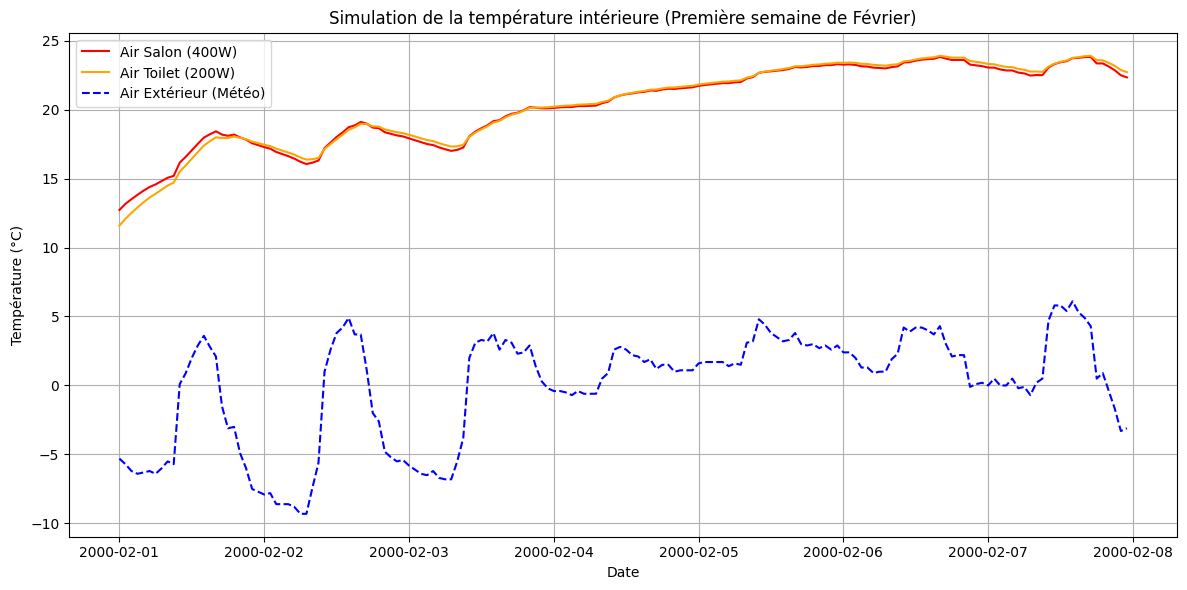

In [ ]:
import matplotlib.pyplot as plt
# 9. LECTURE DES DONNÉES MÉTÉO (Grenoble)
filename = 'FRA_AR_Grenoble.074850_TMYx.epw'

# On FORCE l'année à 2000 pour éviter les sauts dans le temps (TMY)
[data, meta] = dm4bem.read_epw(filename, coerce_year=2000)

# On utilise donc l'année 2000 pour notre extraction
start_date = '2000-02-01 00:00:00'
end_date = '2000-02-07 23:00:00'

# Extraction de la température de l'air
T_ext_data = data['temp_air']

# 10. CRÉATION DU DATASET DES ENTRÉES (u)
input_data_set = pd.DataFrame(index=T_ext_data.index)

input_data_set['T_ext'] = T_ext_data
input_data_set['Q_HVAC_salon'] = 400.0
input_data_set['Q_HVAC_toilet'] = 200.0
input_data_set['Q_sun_out_salon'] = 0.0
input_data_set['Q_sun_in_salon'] = 0.0
input_data_set['Q_sun_in_toilet'] = 0.0
input_data_set['Q_sun_out_toilet'] = 0.0

input_data_set = input_data_set.loc[start_date:end_date]

u = dm4bem.inputs_in_time(us, input_data_set)
# 11. PARAMÈTRES DE LA BOUCLE TEMPORELLE
dt = 3600 # Pas de temps de 1 heure

As_np = As.values
Bs_np = Bs.values
Cs_np = Cs.values
Ds_np = Ds.values
u_np = u.values

I = np.eye(As_np.shape[0])

# Vecteur d'état theta pour stocker les températures de l'inertie
theta = np.zeros([As_np.shape[0], u_np.shape[0]])

# Conditions initiales : On suppose qu'il fait 10°C dans les murs au début
theta[:, 0] = 10.0

# 12. BOUCLE DE SIMULATION DYNAMIQUE (EULER IMPLICITE)

Euler_implicit_matrix = np.linalg.inv(I - dt * As_np)

for k in range(u_np.shape[0] - 1):
    theta[:, k+1] = Euler_implicit_matrix @ (theta[:, k] + dt * Bs_np @ u_np[k, :])

# 13. EXTRACTION DES TEMPÉRATURES OBSERVÉES ET AFFICHAGE
y = (Cs_np @ theta + Ds_np @ u_np.T).T

y_pd = pd.DataFrame(y, index=input_data_set.index, columns=['T_air_salon', 'T_air_toilet'])

plt.figure(figsize=(12, 6))
plt.plot(y_pd.index, y_pd['T_air_salon'], label='Air Salon (400W)', color='red')
plt.plot(y_pd.index, y_pd['T_air_toilet'], label='Air Toilet (200W)', color='orange')
plt.plot(input_data_set.index, input_data_set['T_ext'], label='Air Extérieur (Météo)', color='blue', linestyle='--')
plt.ylabel('Température (°C)')
plt.xlabel('Date')
plt.title("Simulation de la température intérieure (Première semaine de Février)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now we add a PID controller to regulate the apartment's temperature.

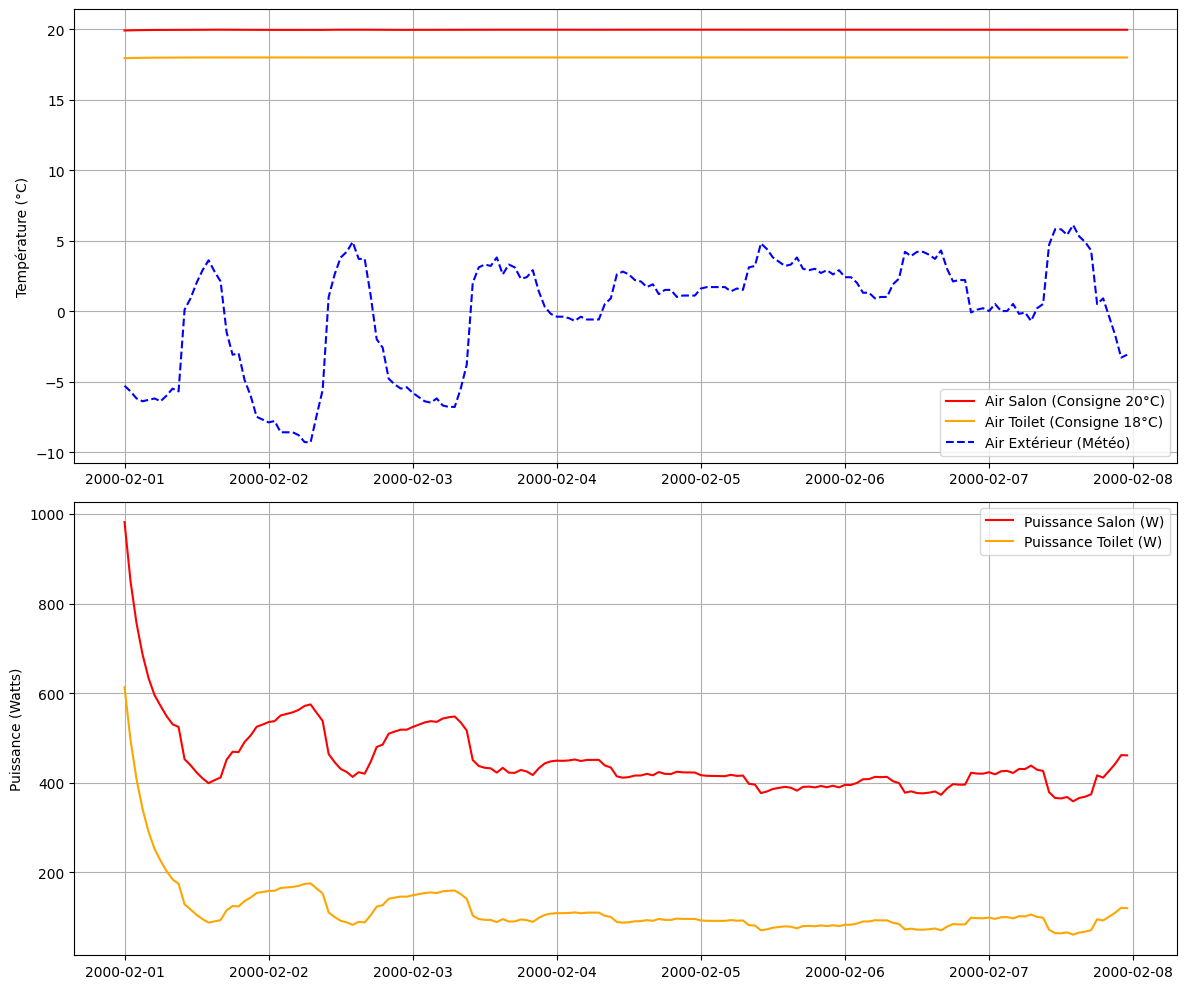

In [ ]:
import numpy as np
import pandas as pd
import dm4bem
import matplotlib.pyplot as plt

# 1. PARAMÈTRES
h_plafond = 2.5
S_fenetre1 = 1.0 * 1.2
S_fenetre2 = 1.0 * 1.2
S_porte = 0.8 * 2.0

S_wall1 = (5.00 + 4.40) * h_plafond - S_fenetre1
S_wall2 = (1.50 + 1.00 + 1.00) * h_plafond - S_fenetre2
S_part = (2.40 + 3.60) * h_plafond - S_porte

e_beton = 0.20
lam_beton = 1.7
e_iso = 0.10
lam_iso = 0.038
e_part = 0.10
lam_part = 0.4

U_fenetre = 1.3
U_porte = 2.0
h_in = 8.0
h_out = 25.0

rho_air = 1.2
c_air = 1000
Debit_VMC_salon = 30.0 / 3600.0
Debit_VMC_toilet = 15.0 / 3600.0

rho_beton = 2400
c_beton = 1000
rho_iso = 50
c_iso = 2100
rho_part = 900
c_part = 1000

# 2. CONDUCTANCES ET CAPACITÉS
G1 = h_out * S_wall1
G2 = (lam_beton / (e_beton / 2)) * S_wall1
G3 = (lam_beton / (e_beton / 2)) * S_wall1
G4 = (lam_iso / (e_iso / 2)) * S_wall1
G5 = (lam_iso / (e_iso / 2)) * S_wall1
G6 = h_in * S_wall1
G_f1 = U_fenetre * S_fenetre1
G_p = U_porte * S_porte

G9 = h_in * S_part
G10 = (lam_part / (e_part / 2)) * S_part
G11 = (lam_part / (e_part / 2)) * S_part
G12 = h_in * S_part

G13 = h_in * S_wall2
G14 = (lam_iso / (e_iso / 2)) * S_wall2
G15 = (lam_iso / (e_iso / 2)) * S_wall2
G16 = (lam_beton / (e_beton / 2)) * S_wall2
G17 = (lam_beton / (e_beton / 2)) * S_wall2
G18 = h_out * S_wall2
G_f2 = U_fenetre * S_fenetre2

G_vmc_salon = rho_air * c_air * Debit_VMC_salon
G_vmc_toilet = rho_air * c_air * Debit_VMC_toilet

Kp = 1e4 # Gain du thermostat

G = np.array([G1, G2, G3, G4, G5, G6, G_f1, G_p, G9, G10, G11, G12, G13, G14, G15, G16, G17, G18, G_f2, G_vmc_salon, G_vmc_toilet, Kp, Kp])

C_beton1 = rho_beton * c_beton * e_beton * S_wall1
C_iso1 = rho_iso * c_iso * e_iso * S_wall1
C_part = rho_part * c_part * e_part * S_part
C_iso2 = rho_iso * c_iso * e_iso * S_wall2
C_beton2 = rho_beton * c_beton * e_beton * S_wall2

C = np.zeros(15)
C[1] = C_beton1
C[3] = C_iso1
C[7] = C_part
C[11] = C_iso2
C[13] = C_beton2

# 3. MATRICE D'INCIDENCE (A)
A = np.zeros((23, 15))
A[0, 0] = 1
A[1, 0], A[1, 1] = -1, 1
A[2, 1], A[2, 2] = -1, 1
A[3, 2], A[3, 3] = -1, 1
A[4, 3], A[4, 4] = -1, 1
A[5, 4], A[5, 5] = -1, 1
A[6, 5] = 1
A[7, 5], A[7, 9] = -1, 1
A[8, 5], A[8, 6] = -1, 1
A[9, 6], A[9, 7] = -1, 1
A[10, 7], A[10, 8] = -1, 1
A[11, 8], A[11, 9] = -1, 1
A[12, 10], A[12, 9] = -1, 1
A[13, 11], A[13, 10] = -1, 1
A[14, 12], A[14, 11] = -1, 1
A[15, 13], A[15, 12] = -1, 1
A[16, 14], A[16, 13] = -1, 1
A[17, 14] = 1
A[18, 9] = 1
A[19, 5] = 1
A[20, 9] = 1
A[21, 5] = 1
A[22, 9] = 1

# 4. ESPACE D'ÉTAT
q_idx = [f"q{i}" for i in range(23)]
th_idx = [f"th{i}" for i in range(15)]

A_pd = pd.DataFrame(A, index=q_idx, columns=th_idx)
G_pd = pd.Series(G, index=q_idx)
C_pd = pd.Series(C, index=th_idx)

# Initialisation stricte avec 0 pour dm4bem
b_pd = pd.Series(0, index=q_idx, dtype=object)
b_pd.loc[[f"q{i}" for i in [0, 6, 17, 18, 19, 20]]] = 'T_ext'
b_pd.loc["q21"] = 'T_set_salon'
b_pd.loc["q22"] = 'T_set_toilet'

f_pd = pd.Series(0, index=th_idx, dtype=object)
f_pd.loc["th0"] = 'Q_sun_out_salon'
f_pd.loc["th4"] = 'Q_sun_in_salon'
f_pd.loc["th10"] = 'Q_sun_in_toilet'
f_pd.loc["th14"] = 'Q_sun_out_toilet'

y_pd = pd.Series(0, index=th_idx)
y_pd.loc["th5"] = 1
y_pd.loc["th9"] = 1

tc = {'A': A_pd, 'G': G_pd, 'C': C_pd, 'b': b_pd, 'f': f_pd, 'y': y_pd}
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(tc)

# 5. MÉTÉO ET ENTRÉES
filename = 'FRA_AR_Grenoble.074850_TMYx.epw'
[data, meta] = dm4bem.read_epw(filename, coerce_year=2000)

start_date = '2000-02-01 00:00:00'
end_date = '2000-02-07 23:00:00'

input_data_set = pd.DataFrame(index=data.index)
input_data_set['T_ext'] = data['temp_air']
input_data_set['T_set_salon'] = 20.0
input_data_set['T_set_toilet'] = 18.0
input_data_set['Q_sun_out_salon'] = 0.0
input_data_set['Q_sun_in_salon'] = 0.0
input_data_set['Q_sun_in_toilet'] = 0.0
input_data_set['Q_sun_out_toilet'] = 0.0

input_data_set = input_data_set.loc[start_date:end_date]
u = dm4bem.inputs_in_time(us, input_data_set)

# 6. SIMULATION DYNAMIQUE
dt = 3600
As_np = As.values
Bs_np = Bs.values
Cs_np = Cs.values
Ds_np = Ds.values
u_np = u.values

I = np.eye(As_np.shape[0])
theta = np.zeros([As_np.shape[0], u_np.shape[0]])
theta[:, 0] = 10.0 # Température initiale des murs

Euler_implicit_matrix = np.linalg.inv(I - dt * As_np)

for k in range(u_np.shape[0] - 1):
    theta[:, k+1] = Euler_implicit_matrix @ (theta[:, k] + dt * Bs_np @ u_np[k, :])

# 7. RÉSULTATS
y = (Cs_np @ theta + Ds_np @ u_np.T).T
y_pd = pd.DataFrame(y, index=input_data_set.index, columns=['T_air_salon', 'T_air_toilet'])

Q_chauffage_salon = Kp * (input_data_set['T_set_salon'] - y_pd['T_air_salon'])
Q_chauffage_toilet = Kp * (input_data_set['T_set_toilet'] - y_pd['T_air_toilet'])

# Affichage graphique
fig, axs = plt.subplots(2, 1, figsize=(12, 10))
axs[0].plot(y_pd.index, y_pd['T_air_salon'], label='Air Salon (Consigne 20°C)', color='red')
axs[0].plot(y_pd.index, y_pd['T_air_toilet'], label='Air Toilet (Consigne 18°C)', color='orange')
axs[0].plot(input_data_set.index, input_data_set['T_ext'], label='Air Extérieur (Météo)', color='blue', linestyle='--')
axs[0].set_ylabel('Température (°C)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(Q_chauffage_salon.index, Q_chauffage_salon, label='Puissance Salon (W)', color='red')
axs[1].plot(Q_chauffage_toilet.index, Q_chauffage_toilet, label='Puissance Toilet (W)', color='orange')
axs[1].set_ylabel('Puissance (Watts)')
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1865/76792295.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_step = pd.date_range(start='2000-01-01', periods=n_hours, freq='H')


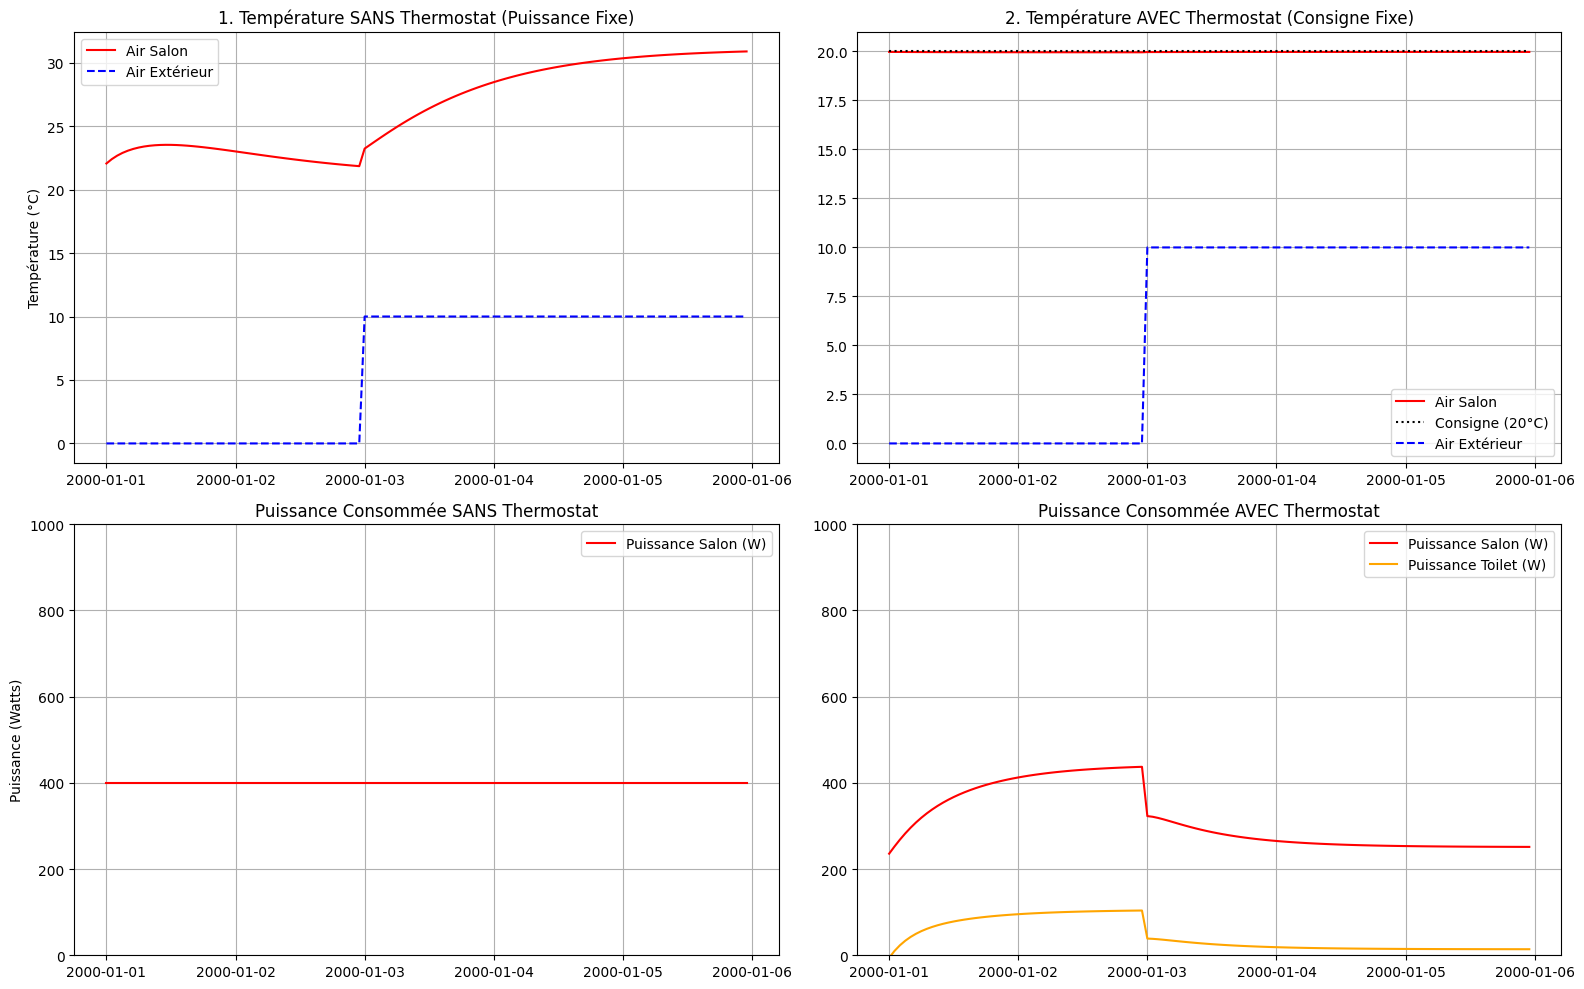

In [ ]:
import numpy as np
import pandas as pd
import dm4bem
import matplotlib.pyplot as plt


# 1. PRÉPARATION DE L'EXPÉRIENCE (120 heures)
n_hours = 120
time_step = pd.date_range(start='2000-01-01', periods=n_hours, freq='H')

# On crée le scénario météo : 0°C pendant 48h, puis on passe à 10°C
T_ext_scenario = np.zeros(n_hours)
T_ext_scenario[48:] = 10.0

# Dataset SANS PID
input_no_pid = pd.DataFrame(index=time_step)
input_no_pid['T_ext'] = T_ext_scenario
input_no_pid['Q_HVAC_salon'] = 400.0
input_no_pid['Q_HVAC_toilet'] = 200.0
input_no_pid['Q_sun_out_salon'] = 0.0
input_no_pid['Q_sun_in_salon'] = 0.0
input_no_pid['Q_sun_in_toilet'] = 0.0
input_no_pid['Q_sun_out_toilet'] = 0.0

# Dataset AVEC PID
input_pid = pd.DataFrame(index=time_step)
input_pid['T_ext'] = T_ext_scenario
input_pid['T_set_salon'] = 20.0
input_pid['T_set_toilet'] = 18.0
input_pid['Q_sun_out_salon'] = 0.0
input_pid['Q_sun_in_salon'] = 0.0
input_pid['Q_sun_in_toilet'] = 0.0
input_pid['Q_sun_out_toilet'] = 0.0


th_idx = [f"th{i}" for i in range(15)]
y_obs = pd.Series(0, index=th_idx)
y_obs.loc["th5"] = 1
y_obs.loc["th9"] = 1

# 2. MODÈLE SANS PID (21 branches, radiateurs constants)
q_idx_no = [f"q{i}" for i in range(21)]
A_no = A[:21, :]
G_no = G[:21]

b_no = pd.Series(0, index=q_idx_no, dtype=object)
b_no.loc[[f"q{i}" for i in [0, 6, 17, 18, 19, 20]]] = 'T_ext'

f_no = pd.Series(0, index=th_idx, dtype=object)
f_no.loc["th0"] = 'Q_sun_out_salon'
f_no.loc["th4"] = 'Q_sun_in_salon'
f_no.loc["th5"] = 'Q_HVAC_salon'
f_no.loc["th9"] = 'Q_HVAC_toilet'
f_no.loc["th10"] = 'Q_sun_in_toilet'
f_no.loc["th14"] = 'Q_sun_out_toilet'

tc_no = {'A': pd.DataFrame(A_no, index=q_idx_no, columns=th_idx),
         'G': pd.Series(G_no, index=q_idx_no),
         'C': pd.Series(C, index=th_idx),
         'b': b_no, 'f': f_no, 'y': y_obs} # <-- On utilise y_obs !

[As_no, Bs_no, Cs_no, Ds_no, us_no] = dm4bem.tc2ss(tc_no)
u_np_no = dm4bem.inputs_in_time(us_no, input_no_pid).values

# 3. MODÈLE AVEC PID (23 branches, thermostats)
tc_pid = {'A': A_pd, 'G': G_pd, 'C': C_pd, 'b': b_pd, 'f': f_pd, 'y': y_obs} # <-- y_obs ici aussi !
[As_pid, Bs_pid, Cs_pid, Ds_pid, us_pid] = dm4bem.tc2ss(tc_pid)
u_np_pid = dm4bem.inputs_in_time(us_pid, input_pid).values

# 4. SIMULATION DES DEUX MODÈLES
dt = 3600
theta_no = np.zeros([As_no.shape[0], u_np_no.shape[0]])
theta_pid = np.zeros([As_pid.shape[0], u_np_pid.shape[0]])

# On démarre avec des murs "chauds" à 20°C
theta_no[:, 0] = 20.0
theta_pid[:, 0] = 20.0

Inv_no = np.linalg.inv(np.eye(As_no.shape[0]) - dt * As_no.values)
Inv_pid = np.linalg.inv(np.eye(As_pid.shape[0]) - dt * As_pid.values)

for k in range(n_hours - 1):
    theta_no[:, k+1] = Inv_no @ (theta_no[:, k] + dt * Bs_no.values @ u_np_no[k, :])
    theta_pid[:, k+1] = Inv_pid @ (theta_pid[:, k] + dt * Bs_pid.values @ u_np_pid[k, :])

# 5. EXTRACTION SÉCURISÉE DES RÉSULTATS
y_res_no = (Cs_no.values @ theta_no + Ds_no.values @ u_np_no.T).T
y_res_pid = (Cs_pid.values @ theta_pid + Ds_pid.values @ u_np_pid.T).T

out_no = pd.DataFrame(y_res_no, index=time_step, columns=['T_air_salon', 'T_air_toilet'])
out_pid = pd.DataFrame(y_res_pid, index=time_step, columns=['T_air_salon', 'T_air_toilet'])

# Consommation électrique du PID
Q_pid_salon = Kp * (input_pid['T_set_salon'] - out_pid['T_air_salon'])
Q_pid_toilet = Kp * (input_pid['T_set_toilet'] - out_pid['T_air_toilet'])

# 6. AFFICHAGE COMPARATIF
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# COLONNE 1 : SANS PID
axs[0, 0].plot(out_no.index, out_no['T_air_salon'], label='Air Salon', color='red')
axs[0, 0].plot(input_no_pid.index, input_no_pid['T_ext'], label='Air Extérieur', color='blue', linestyle='--')
axs[0, 0].set_title("1. Température SANS Thermostat (Puissance Fixe)")
axs[0, 0].set_ylabel('Température (°C)')
axs[0, 0].legend(); axs[0, 0].grid(True)

axs[1, 0].plot(input_no_pid.index, input_no_pid['Q_HVAC_salon'], label='Puissance Salon (W)', color='red')
axs[1, 0].set_title("Puissance Consommée SANS Thermostat")
axs[1, 0].set_ylabel('Puissance (Watts)')
axs[1, 0].set_ylim(0, 1000)
axs[1, 0].legend(); axs[1, 0].grid(True)

# COLONNE 2 : AVEC PID
axs[0, 1].plot(out_pid.index, out_pid['T_air_salon'], label='Air Salon', color='red')
axs[0, 1].plot(input_pid.index, input_pid['T_set_salon'], label='Consigne (20°C)', color='black', linestyle=':')
axs[0, 1].plot(input_pid.index, input_pid['T_ext'], label='Air Extérieur', color='blue', linestyle='--')
axs[0, 1].set_title("2. Température AVEC Thermostat (Consigne Fixe)")
axs[0, 1].legend(); axs[0, 1].grid(True)

axs[1, 1].plot(Q_pid_salon.index, Q_pid_salon, label='Puissance Salon (W)', color='red')
axs[1, 1].plot(Q_pid_toilet.index, Q_pid_toilet, label='Puissance Toilet (W)', color='orange')
axs[1, 1].set_title("Puissance Consommée AVEC Thermostat")
axs[1, 1].set_ylim(0, 1000)
axs[1, 1].legend(); axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1865/3522697431.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_step = pd.date_range(start='2000-01-01', periods=n_hours, freq='H')


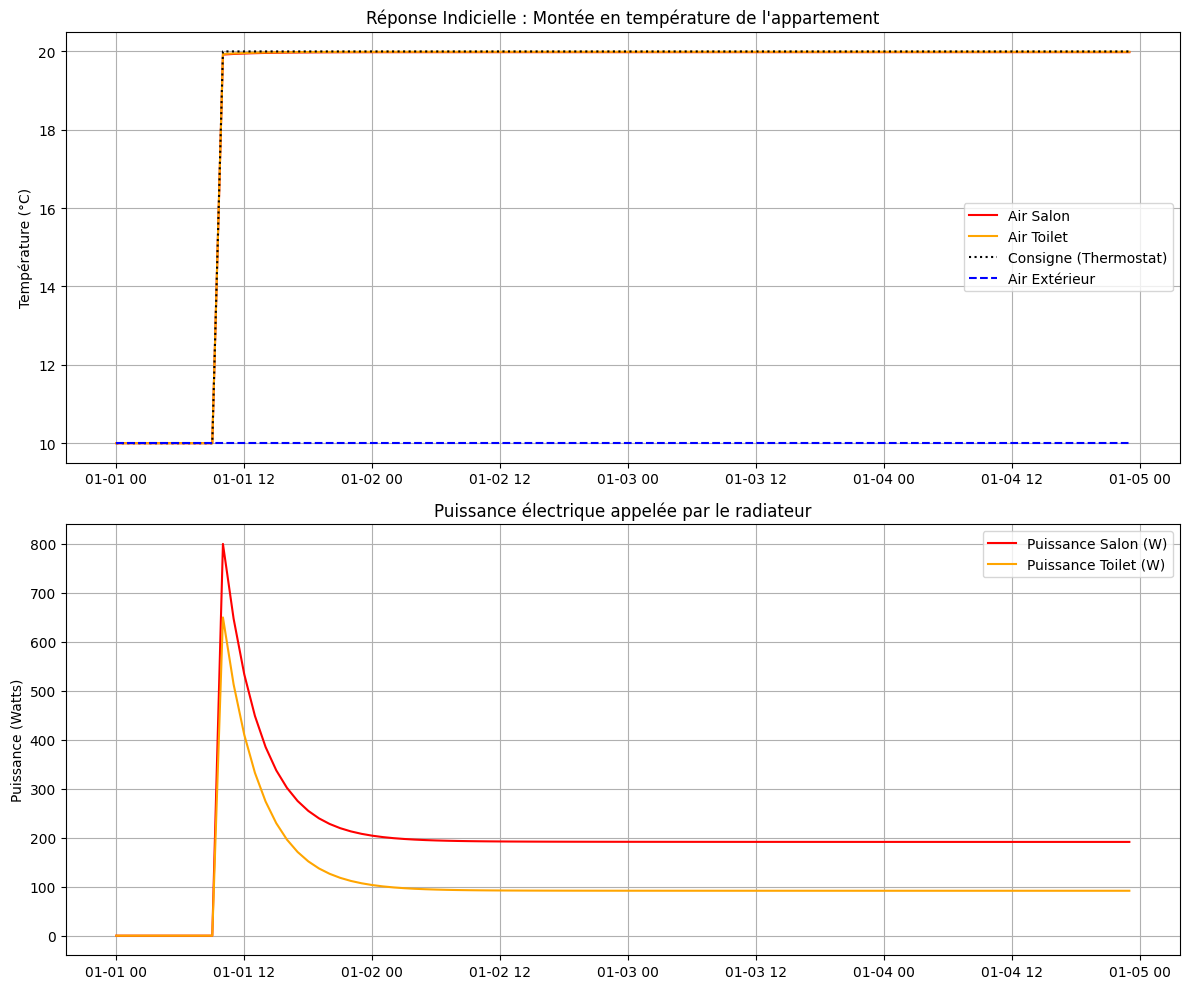

In [ ]:
# 14. RÉPONSE INDICIELLE (STEP RESPONSE)

# On crée une ligne de temps théorique de 4 jours (96 heures)
n_hours = 96
time_step = pd.date_range(start='2000-01-01', periods=n_hours, freq='H')

# Création du dataset d'entrée pour le Step
input_step = pd.DataFrame(index=time_step)

# Avant le "Step" : Tout est à l'équilibre à 10°C
input_step['T_ext'] = 10.0
input_step['T_set_salon'] = 10.0
input_step['T_set_toilet'] = 10.0
input_step['Q_sun_out_salon'] = 0.0
input_step['Q_sun_in_salon'] = 0.0
input_step['Q_sun_in_toilet'] = 0.0
input_step['Q_sun_out_toilet'] = 0.0

# LE CHOC (STEP) : À la 10ème heure, on monte le thermostat à 20°C
input_step.loc[time_step[10]:, 'T_set_salon'] = 20.0
input_step.loc[time_step[10]:, 'T_set_toilet'] = 20.0

# Alignement avec l'espace d'état
u_step = dm4bem.inputs_in_time(us, input_step).values

# Préparation du vecteur d'état
theta_step = np.zeros([As_np.shape[0], u_step.shape[0]])
theta_step[:, 0] = 10.0 # La température des murs (béton/isolant) commence à 10°C

# Recalcul de la matrice d'Euler (par sécurité)
I = np.eye(As_np.shape[0])
Euler_implicit_matrix = np.linalg.inv(I - dt * As_np)

# Boucle de simulation d'Euler pour le Step
for k in range(u_step.shape[0] - 1):
    theta_step[:, k+1] = Euler_implicit_matrix @ (theta_step[:, k] + dt * Bs_np @ u_step[k, :])

# Extraction des températures de l'air
y_step = (Cs_np @ theta_step + Ds_np @ u_step.T).T
y_step_pd = pd.DataFrame(y_step, index=time_step, columns=['T_air_salon', 'T_air_toilet'])

# Calcul de la puissance appelée lors du Step (Chauffage)
Q_step_salon = Kp * (input_step['T_set_salon'] - y_step_pd['T_air_salon'])
Q_step_toilet = Kp * (input_step['T_set_toilet'] - y_step_pd['T_air_toilet'])

# Affichage Graphique du Step Response
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Graphe des températures (On verra l'inertie thermique)
axs[0].plot(y_step_pd.index, y_step_pd['T_air_salon'], label='Air Salon', color='red')
axs[0].plot(y_step_pd.index, y_step_pd['T_air_toilet'], label='Air Toilet', color='orange')
axs[0].plot(input_step.index, input_step['T_set_salon'], label='Consigne (Thermostat)', color='black', linestyle=':')
axs[0].plot(input_step.index, input_step['T_ext'], label='Air Extérieur', color='blue', linestyle='--')
axs[0].set_ylabel('Température (°C)')
axs[0].set_title("Réponse Indicielle : Montée en température de l'appartement")
axs[0].legend()
axs[0].grid(True)

# Graphe de la puissance (Le pic d'allumage)
axs[1].plot(Q_step_salon.index, Q_step_salon, label='Puissance Salon (W)', color='red')
axs[1].plot(Q_step_toilet.index, Q_step_toilet, label='Puissance Toilet (W)', color='orange')
axs[1].set_ylabel('Puissance (Watts)')
axs[1].set_title("Puissance électrique appelée par le radiateur")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()